# Lab 8: Cross-Lingual Transfer and Layer Freezing in mBERT

**Paper:** Wu & Dredze (2019) — *Beto, Bentz, Becas: The Surprising Cross-Lingual Effectiveness of BERT* (EMNLP 2019)

**Goal:** Investigate mBERT's zero-shot cross-lingual transfer on NLI (XNLI) and how layer freezing affects performance.

**Approach:**
- Fine-tune mBERT on English MultiNLI (50K subset), evaluate zero-shot on 6 XNLI languages
- Replicate the paper's Section 5.2: freeze bottom n layers during fine-tuning
- Novel extension: freeze top n layers instead

**Hypotheses:**
1. Baseline zero-shot transfer results will roughly match the paper (within a few points, accounting for our 50K training subset vs full 393K)
2. Freezing bottom layers won't necessarily improve performance — why would training fewer parameters help?
3. Freezing top layers won't necessarily hurt or help — the model may adapt regardless

**Languages:** en, fr, de, zh, ar, hi (covering close/distant, same/different script)

In [2]:
# Same conda env as lab7 — see lab7.ipynb cell 1 for kernel setup instructions
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import BertForSequenceClassification, AutoTokenizer, get_linear_schedule_with_warmup
from datasets import load_dataset
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
from tqdm.auto import tqdm
import gc
import time

sns.set_style("whitegrid")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Hyperparameters (matching paper Section 5)
MODEL_NAME = "bert-base-multilingual-cased"
MAX_LENGTH = 128
BATCH_SIZE = 32
LEARNING_RATE = 3e-5
EPOCHS = 3
TRAIN_SUBSET = 50_000
EVAL_LANGUAGES = ["en", "fr", "de", "zh", "ar", "hi"]

/home/jay/miniconda3/envs/experimental/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU: NVIDIA GeForce RTX 4080 Laptop GPU


In [3]:
# Load mBERT tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Training data: MultiNLI English (50K random subset)
# The paper trains on full MultiNLI (~393K), we subsample for speed
print("Loading MultiNLI training data...")
mnli = load_dataset("multi_nli", split="train")
mnli = mnli.filter(lambda x: x["label"] != -1)  # Remove examples without gold labels
mnli = mnli.shuffle(seed=SEED).select(range(TRAIN_SUBSET))

def tokenize_fn(examples):
    return tokenizer(
        examples["premise"], examples["hypothesis"],
        truncation=True, max_length=MAX_LENGTH, padding="max_length"
    )

train_ds = mnli.map(tokenize_fn, batched=True, batch_size=1000)
train_ds.set_format("torch", columns=["input_ids", "attention_mask", "token_type_ids", "label"])
print(f"Training set: {len(train_ds)} examples")

# Evaluation data: XNLI test set for each target language
# The paper evaluates on all 15 XNLI languages; we use 6 representative ones
print("\nLoading XNLI evaluation data...")
eval_datasets = {}
for lang in EVAL_LANGUAGES:
    ds = load_dataset("xnli", lang, split="test")
    ds = ds.map(tokenize_fn, batched=True, batch_size=1000)
    ds.set_format("torch", columns=["input_ids", "attention_mask", "token_type_ids", "label"])
    eval_datasets[lang] = ds
    print(f"  {lang}: {len(ds)} examples")

print(f"\nSample (en): {mnli[0]['premise'][:80]}...")
print(f"  Hypothesis: {mnli[0]['hypothesis'][:80]}...")
print(f"  Label: {mnli[0]['label']} (0=entailment, 1=neutral, 2=contradiction)")

Loading MultiNLI training data...


Map: 100%|██████████| 50000/50000 [00:03<00:00, 15938.57 examples/s]


Training set: 50000 examples

Loading XNLI evaluation data...


Map: 100%|██████████| 5010/5010 [00:00<00:00, 27972.52 examples/s]


  en: 5010 examples


...

  zh: 5010 examples


Map: 100%|██████████| 5010/5010 [00:00<00:00, 26205.74 examples/s]


  ar: 5010 examples


Map: 100%|██████████| 5010/5010 [00:00<00:00, 21118.44 examples/s]

  hi: 5010 examples

Sample (en): I'll hurry over that part....
  Hypothesis: "I'll be quick with that part."...
  Label: 0 (0=entailment, 1=neutral, 2=contradiction)


In [ ]:
## Model Architecture & Layer Freezing

# The paper's approach:
# - **Architecture:** mBERT encoder (`bert-base-multilingual-cased`, 12 transformer blocks) + linear classifier on [CLS] token (768 -> 3 classes)
# - **Fine-tuning:** Train on English, evaluate zero-shot on target languages
# - **Layer numbering:** Layer 0 = embedding, Layers 1-12 = transformer blocks

# **Freezing strategies:**
# - **Freeze bottom n:** Fix embedding + first n transformer blocks. The intuition from the paper is that lower layers capture language-specific features, so freezing them preserves the cross-lingual representation.
# - **Freeze top n (novel):** Fix the last n transformer blocks. These capture more task/language-specific semantics.

In [4]:
def apply_freeze(model, freeze_type=None, n=0):
    """Apply layer freezing to mBERT.

    Paper's convention:
        Layer 0 = embedding layer (model.bert.embeddings)
        Layers 1-12 = transformer blocks (model.bert.encoder.layer[0..11])

    freeze_type="bottom", n=K: freeze embedding + first K transformer blocks
    freeze_type="top", n=K: freeze last K transformer blocks
    freeze_type=None: baseline, everything trainable
    """
    if freeze_type is None:
        return

    if freeze_type == "bottom":
        # Freeze embedding layer
        for param in model.bert.embeddings.parameters():
            param.requires_grad = False
        # Freeze first n transformer blocks
        for i in range(n):
            for param in model.bert.encoder.layer[i].parameters():
                param.requires_grad = False

    elif freeze_type == "top":
        # Freeze last n transformer blocks
        for i in range(12 - n, 12):
            for param in model.bert.encoder.layer[i].parameters():
                param.requires_grad = False

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"  Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")


def evaluate(model, dataset, batch_size=64):
    """Compute accuracy on a dataset."""
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size)
    correct = total = 0
    with torch.no_grad():
        for batch in loader:
            inputs = {k: batch[k].to(device) for k in ["input_ids", "attention_mask", "token_type_ids"]}
            labels = batch["label"].to(device)
            with autocast():
                logits = model(**inputs).logits
            correct += (logits.argmax(dim=-1) == labels).sum().item()
            total += labels.size(0)
    return correct / total


def run_experiment(name, freeze_type, n, train_ds, eval_datasets):
    """Fine-tune mBERT with a given freeze config, return per-language accuracy."""
    print(f"\n{'='*60}")
    print(f"Experiment: {name}")
    print(f"{'='*60}")

    # Fresh model for each experiment
    model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3).to(device)
    apply_freeze(model, freeze_type, n)

    # Optimizer: only update unfrozen parameters
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=LEARNING_RATE, betas=(0.9, 0.999), weight_decay=0.01
    )

    # LR schedule: 10% linear warmup, then linear decay to 0
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    total_steps = len(train_loader) * EPOCHS
    warmup_steps = int(0.1 * total_steps)
    scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
    scaler = GradScaler()

    # Train
    start = time.time()
    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)
        for batch in pbar:
            optimizer.zero_grad()
            inputs = {k: batch[k].to(device) for k in ["input_ids", "attention_mask", "token_type_ids"]}
            labels = batch["label"].to(device)

            with autocast():
                outputs = model(**inputs, labels=labels)
                loss = outputs.loss

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            epoch_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.3f}")

        print(f"  Epoch {epoch+1}: avg loss = {epoch_loss / len(train_loader):.4f}")

    elapsed = time.time() - start
    print(f"  Training time: {elapsed:.0f}s")

    # Evaluate zero-shot on all target languages
    results = {}
    for lang, ds in eval_datasets.items():
        acc = evaluate(model, ds)
        results[lang] = acc
        print(f"  {lang}: {100*acc:.1f}%")

    # Free GPU memory before next experiment
    del model, optimizer, scheduler, scaler
    torch.cuda.empty_cache()
    gc.collect()

    return results

## Run All Experiments

8 experiments total (~3-4 min each):
1. **Baseline** — fine-tune all layers
2. **Freeze bottom 0** — freeze only embeddings (paper's "Lay 0")
3. **Freeze bottom 3/6/9** — freeze embeddings + first 3/6/9 transformer blocks
4. **Freeze top 3/6/9** — freeze last 3/6/9 transformer blocks (novel)

In [5]:
# Define all experiments: (name, freeze_type, n)
experiments = [
    ("baseline",        None,     0),
    ("freeze_bottom_0", "bottom", 0),  # Paper's "Lay 0" — embed only
    ("freeze_bottom_3", "bottom", 3),  # Paper's "Lay 3"
    ("freeze_bottom_6", "bottom", 6),  # Paper's "Lay 6"
    ("freeze_bottom_9", "bottom", 9),  # Paper's "Lay 9"
    ("freeze_top_3",    "top",    3),  # Novel: freeze layers 10-12
    ("freeze_top_6",    "top",    6),  # Novel: freeze layers 7-12
    ("freeze_top_9",    "top",    9),  # Novel: freeze layers 4-12
]

all_results = {}
total_start = time.time()

for name, freeze_type, n in experiments:
    all_results[name] = run_experiment(name, freeze_type, n, train_ds, eval_datasets)

total_elapsed = time.time() - total_start
print(f"\n{'='*60}")
print(f"All experiments complete in {total_elapsed/60:.1f} minutes")
print(f"{'='*60}")


Experiment: baseline


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1205.50it/s, Materializing param=bert.pooler.dense.weight]                              
BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSIN

  Epoch 1: avg loss = 0.7655


  Epoch 2: avg loss = 0.5148


/tmp/ipykernel_23558/2325985783.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


...

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2081.52it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSI

  Trainable: 114,064,899 / 177,855,747 (64.1%)


  Epoch 1: avg loss = 0.9254


  Epoch 2: avg loss = 0.7141


  Epoch 3: avg loss = 0.6055
  Training time: 433s
  en: 69.2%
  fr: 62.0%
  de: 60.5%
  zh: 58.1%
  ar: 56.5%
  hi: 52.0%

All experiments complete in 60.5 minutes


## Results

In [6]:
# Results table
print("Accuracy (%) by language and freeze config")
print("=" * 80)

# Paper's reported values for comparison (Table 3, XNLI zero-shot)
paper_values = {"en": 82.1, "fr": 73.8, "de": 71.1, "zh": 69.3, "ar": 64.9, "hi": 60.0}

header = f"{'Config':<20}" + "".join(f"{lang:>8}" for lang in EVAL_LANGUAGES) + f"{'Avg(-en)':>10}"
print(header)
print("-" * 80)

# Paper baseline row
paper_avg = np.mean([paper_values[l] for l in EVAL_LANGUAGES if l != "en"])
print(f"{'paper (full data)':<20}" + "".join(f"{paper_values[l]:>8.1f}" for l in EVAL_LANGUAGES) + f"{paper_avg:>10.1f}")
print("-" * 80)

# Our results
for name, results in all_results.items():
    cross_avg = np.mean([100 * results[l] for l in EVAL_LANGUAGES if l != "en"])
    row = f"{name:<20}" + "".join(f"{100*results[l]:>8.1f}" for l in EVAL_LANGUAGES) + f"{cross_avg:>10.1f}"
    print(row)

Accuracy (%) by language and freeze config
Config                    en      fr      de      zh      ar      hi  Avg(-en)
--------------------------------------------------------------------------------
paper (full data)       82.1    73.8    71.1    69.3    64.9    60.0      67.8
--------------------------------------------------------------------------------
baseline                75.7    70.5    68.4    66.8    61.8    58.3      65.2
freeze_bottom_0         76.5    69.3    66.8    65.8    62.3    57.0      64.2
freeze_bottom_3         75.9    70.0    66.4    65.7    62.4    58.2      64.5
freeze_bottom_6         75.9    70.2    68.0    66.2    63.2    59.2      65.3
freeze_bottom_9         72.7    66.7    64.9    64.1    59.1    55.5      62.1
freeze_top_3            75.1    68.3    67.2    65.8    62.2    57.6      64.2
freeze_top_6            72.2    66.5    64.3    62.2    59.9    56.7      61.9
freeze_top_9            69.2    62.0    60.5    58.1    56.5    52.0      57.8


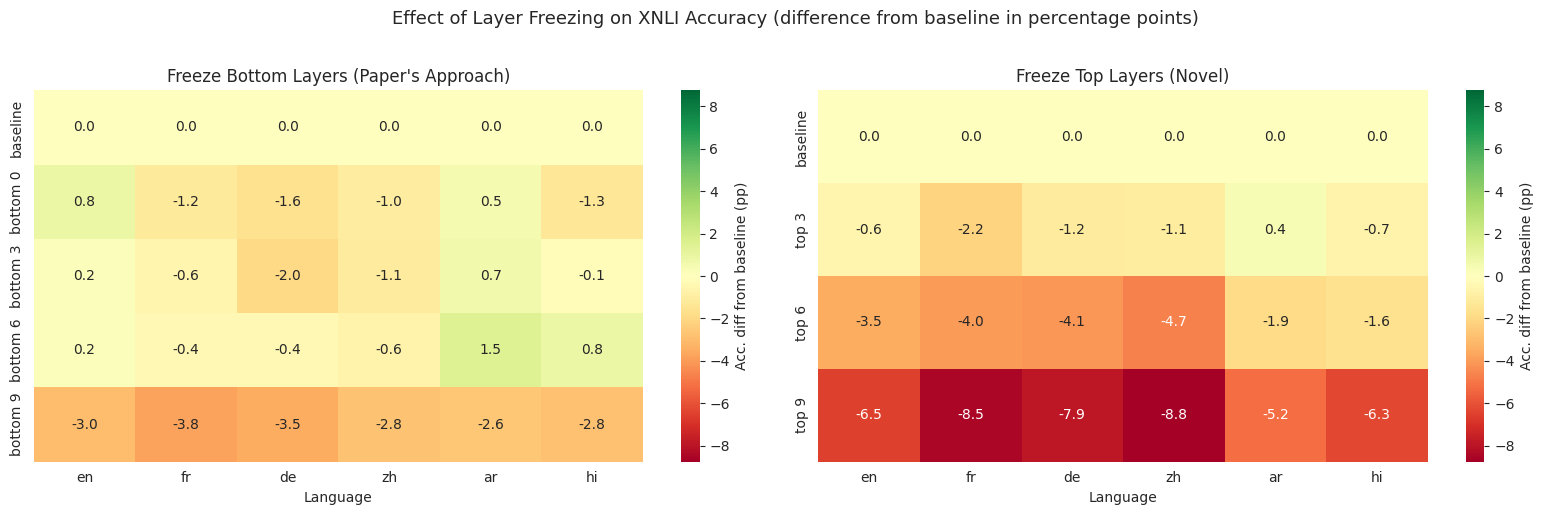

In [7]:
# Heatmap: difference from baseline (replicating paper's Figure 1 style)
baseline = all_results["baseline"]
config_names = list(all_results.keys())
diff_matrix = np.zeros((len(config_names), len(EVAL_LANGUAGES)))

for i, name in enumerate(config_names):
    for j, lang in enumerate(EVAL_LANGUAGES):
        diff_matrix[i, j] = 100 * (all_results[name][lang] - baseline[lang])

fig, axes = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={"width_ratios": [1, 1]})

# Split into bottom-freeze and top-freeze for clarity
bottom_names = ["baseline", "freeze_bottom_0", "freeze_bottom_3", "freeze_bottom_6", "freeze_bottom_9"]
top_names = ["baseline", "freeze_top_3", "freeze_top_6", "freeze_top_9"]

for ax, names, title in [
    (axes[0], bottom_names, "Freeze Bottom Layers (Paper's Approach)"),
    (axes[1], top_names, "Freeze Top Layers (Novel)"),
]:
    indices = [config_names.index(n) for n in names]
    data = diff_matrix[indices]
    display_names = [n.replace("freeze_", "").replace("_", " ") for n in names]

    vmax = max(abs(diff_matrix.min()), abs(diff_matrix.max()), 3)
    sns.heatmap(
        data, annot=True, fmt=".1f", cmap="RdYlGn", center=0,
        xticklabels=EVAL_LANGUAGES, yticklabels=display_names,
        vmin=-vmax, vmax=vmax, ax=ax, cbar_kws={"label": "Acc. diff from baseline (pp)"}
    )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Language")

fig.suptitle("Effect of Layer Freezing on XNLI Accuracy (difference from baseline in percentage points)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

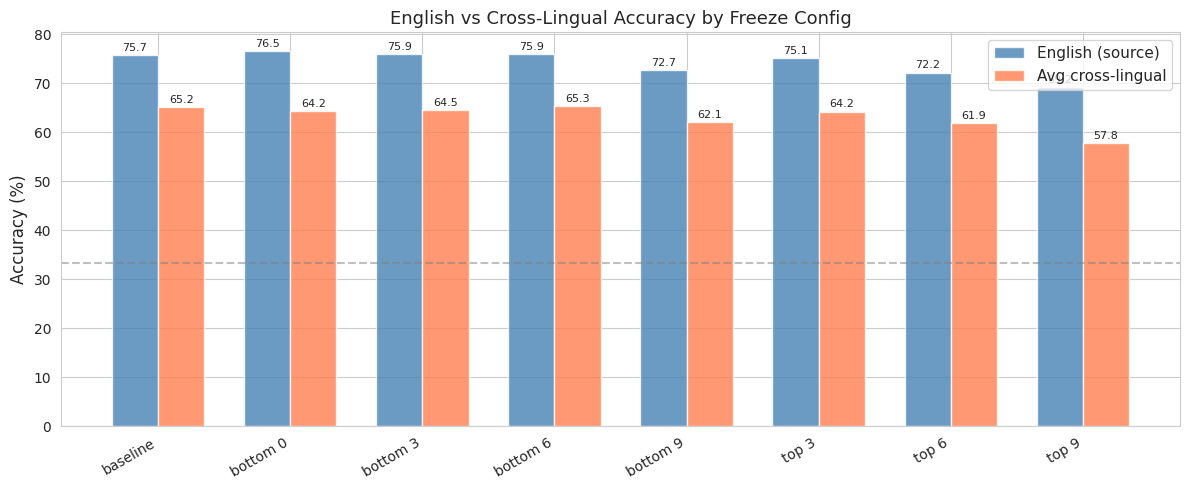

In [8]:
# Bar chart: average cross-lingual accuracy (excluding English)
fig, ax = plt.subplots(figsize=(12, 5))

names = list(all_results.keys())
display_names = [n.replace("freeze_", "").replace("_", " ") for n in names]
cross_avgs = [np.mean([100 * all_results[n][l] for l in EVAL_LANGUAGES if l != "en"]) for n in names]
en_accs = [100 * all_results[n]["en"] for n in names]

x = np.arange(len(names))
width = 0.35
bars1 = ax.bar(x - width/2, en_accs, width, label="English (source)", color="steelblue", alpha=0.8)
bars2 = ax.bar(x + width/2, cross_avgs, width, label="Avg cross-lingual", color="coral", alpha=0.8)

ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("English vs Cross-Lingual Accuracy by Freeze Config", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(display_names, rotation=30, ha="right", fontsize=10)
ax.legend(fontsize=11)
ax.axhline(y=33.3, color="gray", linestyle="--", alpha=0.5, label="chance (33.3%)")

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.1f}", xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

## Analysis & Hypothesis Evaluation

### Hypothesis 1: Baseline results roughly match the paper
*Compare our baseline row to the paper's reported values above. We use 50K training examples vs their 393K, so expect ~2-5 points lower across the board.*

### Hypothesis 2: Freezing bottom layers won't improve performance
*The paper found that freezing bottom 6 layers gave the best improvement for sentence-level tasks (NLI, document classification). Look at the freeze_bottom_6 row in the heatmap. Does it show consistent improvement over baseline?*

*If it does improve: one explanation is that the lower layers of mBERT encode cross-lingual structure learned during pretraining. When you fine-tune them on English, they overfit to English-specific features and lose their cross-lingual generality. Freezing them preserves this cross-lingual bridge.*

### Hypothesis 3: Freezing top layers won't necessarily hurt or help
*This is our novel experiment. The top layers capture more task-specific and language-specific semantics. Freezing them means the model must solve the task using only the lower/middle layers' ability to adapt. How does this compare to freezing the bottom?*

### Key questions:
1. Which freezing strategy gives the best cross-lingual transfer?
2. Is there a trade-off between English accuracy and cross-lingual accuracy?
3. Does the pattern differ for close languages (fr, de) vs distant languages (zh, ar, hi)?